<a href="https://colab.research.google.com/github/nishtha-09-gupta/AirbnbDATAanalysis/blob/main/notebooks/A3_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Airbnb_Cleaned.csv")

In [4]:
df.describe()

,id,host_id,lat,long,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
count,9.805700e+04,9.805700e+04,98049.000000,98049.000000,97891.000000,97822.000000,97795.000000,98057.000000,97931.000000,98057.000000,97779.000000,97767.000000,98057.000000
mean,2.981992e+07,4.925044e+10,40.727980,-73.949341,2012.490556,625.857282,125.142748,8.147567,27.183231,1.293741,3.286871,8.055510,134.418298
std,1.599170e+07,2.854288e+10,0.055971,0.049861,5.764045,331.706499,66.333950,28.653840,48.918785,1.632960,1.279480,32.671494,129.815853
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,1.000000,0.000000,0.010000,1.000000,1.000000,0.000000
25%,1.620671e+07,2.456725e+10,40.688680,-73.982510,2008.000000,340.000000,68.000000,2.000000,1.000000,0.290000,2.000000,1.000000,2.000000
50%,2.995898e+07,4.911989e+10,40.722160,-73.954320,2012.000000,626.000000,125.000000,3.000000,7.000000,0.760000,3.000000,1.000000,90.000000
75%,4.354721e+07,7.398276e+10,40.762690,-73.931910,2017.000000,913.000000,183.000000,5.000000,30.000000,1.740000,4.000000,2.000000,254.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,365.000000


In [5]:
df.describe(include='object')

,name,host_identity_verified,host_name,neighbourhood_group,neighbourhood,country,country_code,instant_bookable,cancellation_policy,room_type,last_review,house_rules
count,97840,98057,97672,98041,98045,98057,97957,97983,98001,98057,83143,98057
unique,58952,2,12921,7,224,1,1,2,3,4,2442,1970
top,Home away from home,unconfirmed,Michael,Manhattan,Bedford-Stuyvesant,United States,US,False,moderate,Entire home/apt,2019-06-23,Not Provided
freq,33,49200,850,41652,7613,98057,97957,49252,32785,51231,2351,50387


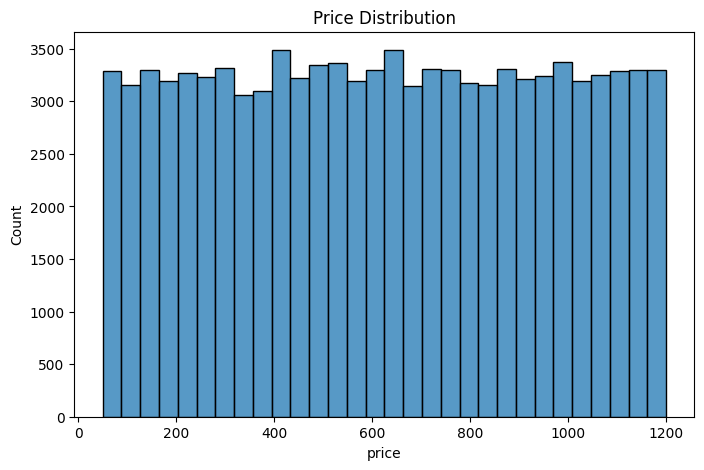

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30)
plt.title("Price Distribution")
plt.show()

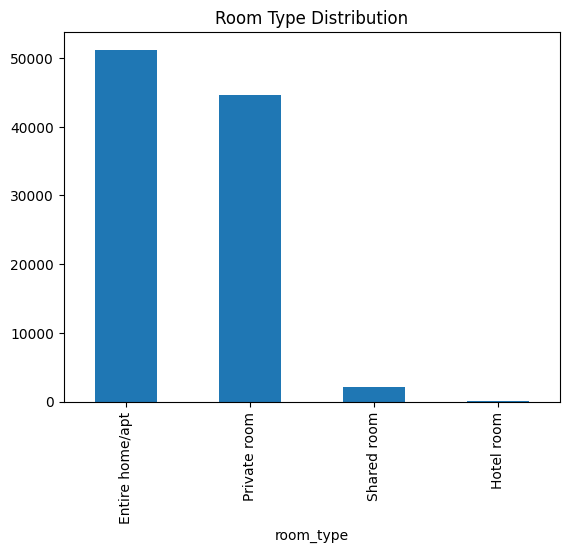

In [8]:
df['room_type'].value_counts().plot(kind='bar')
plt.title("Room Type Distribution")
plt.show()

In [9]:
df.isnull().sum()

,0
id,0
name,217
host_id,0
host_identity_verified,0
host_name,385
neighbourhood_group,16
neighbourhood,12
lat,8
long,8
country,0


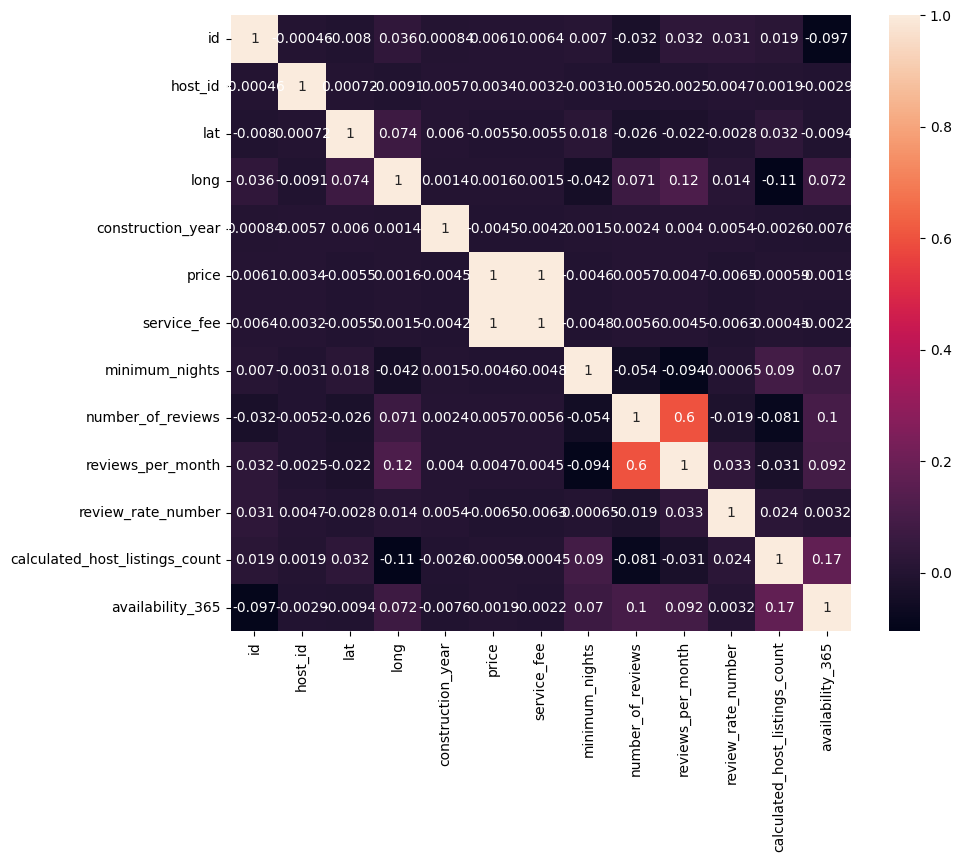

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

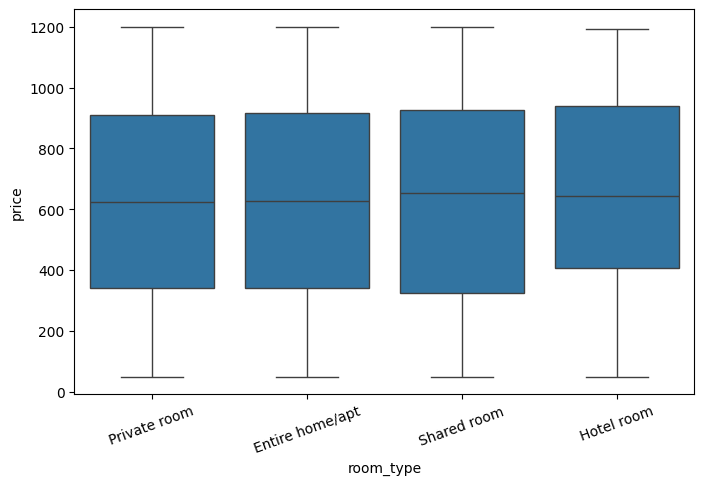

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.xticks(rotation=20)
plt.show()

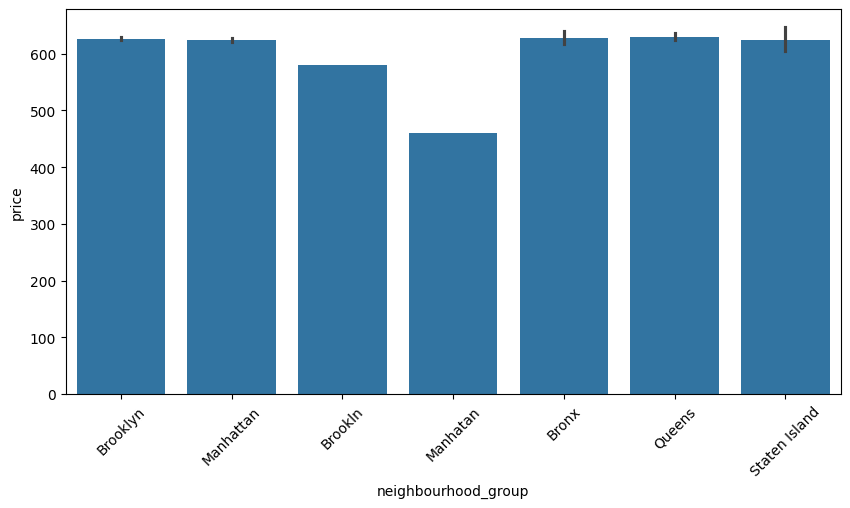

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='neighbourhood_group',
    y='price',
    estimator=np.mean
)
plt.xticks(rotation=45)
plt.show()

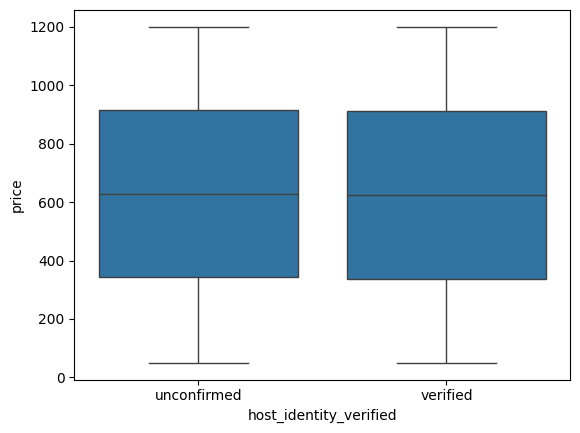

In [15]:
sns.boxplot(
    x='host_identity_verified',
    y='price',
    data=df
)
plt.show()

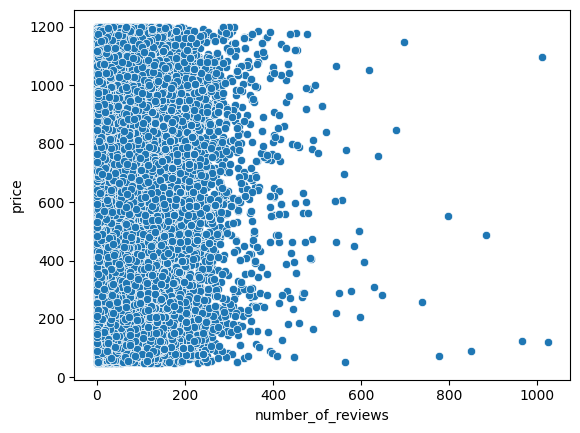

In [17]:
sns.scatterplot(
    data=df,
    x='number_of_reviews',
    y='price'
)
plt.show()

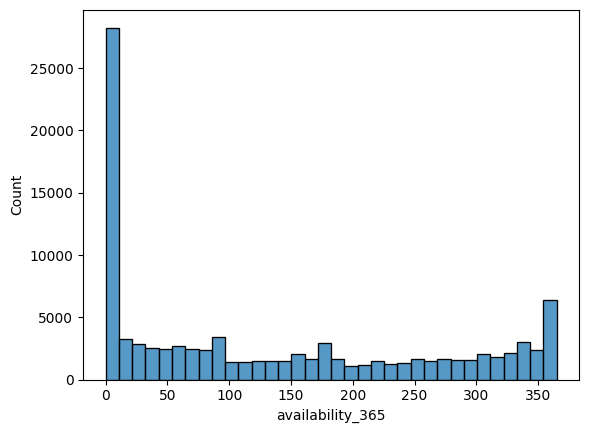

In [19]:
sns.histplot(df['availability_365'])
plt.show()

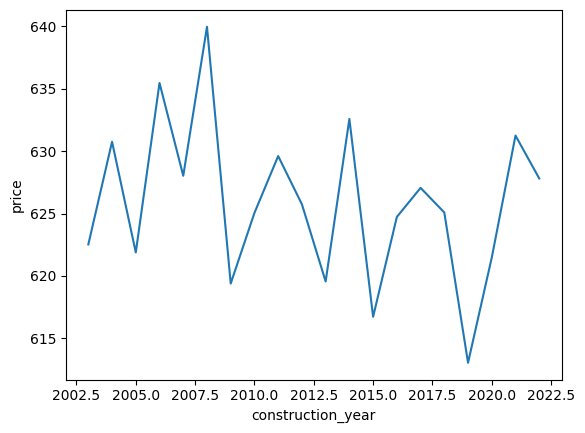

In [22]:
sns.lineplot(
    data=df.groupby('construction_year')['price'].mean().reset_index(),
    x='construction_year',
    y='price'
)
plt.show()

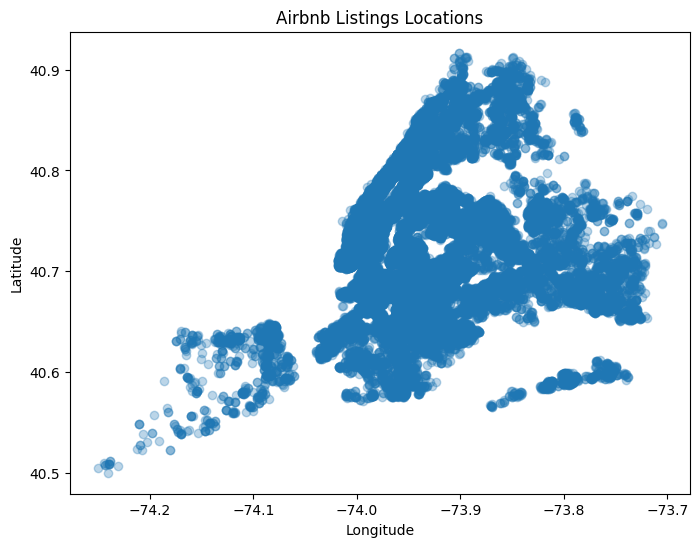

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['long'],
    df['lat'],
    alpha=0.3
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Airbnb Listings Locations")
plt.show()